# Pre-Experiment Power Analysis & Sample Size Sizing
## Product Monetization & Conversion Rate Optimization

### Objective
Determine the minimum sample size required per variant before launching the A/B experiment to guarantee statistical power ($1 - \beta = 0.80$) at a significance level ($\alpha = 0.05$).

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
from statsmodels.stats.power import NormalIndPower

# Visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11

### 1. Baseline Parameters & Effect Size Calculation
We calculate **Cohen's h**, which measures the statistical effect size between two proportions.

In [8]:
# Experiment constraints
baseline_cr = 0.050      # Baseline conversion rate (5.0%)
mde_relative = 0.20      # Target Minimum Detectable Effect (+20% relative)
target_cr = baseline_cr * (1 + mde_relative)  # Expected variant CR (6.0%)
alpha = 0.05             # Significance level (Type I error threshold)
power = 0.80             # Statistical power (1 - Type II error)

# Calculate Cohen's h for proportion difference
effect_size = sms.proportion_effectsize(baseline_cr, target_cr)

# Compute sample size per variant using NormalIndPower
power_analysis = NormalIndPower()
required_n_per_variant = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1.0,
    alternative='two-sided'
)

required_n = int(np.ceil(required_n_per_variant))
total_n = required_n * 2

print(f"Baseline Conversion: {baseline_cr * 100:.2f}%")
print(f"Target Conversion (MDE +20%): {target_cr * 100:.2f}%")
print(f"Calculated Effect Size (Cohen's h): {effect_size:.4f}")
print(f"Required Sample Size per Variant: {required_n:,} users")
print(f"Total Experiment Sample Required: {total_n:,} users")

Baseline Conversion: 5.00%
Target Conversion (MDE +20%): 6.00%
Calculated Effect Size (Cohen's h): -0.0439
Required Sample Size per Variant: 8,143 users
Total Experiment Sample Required: 16,286 users


### 2. Power Curve Sensitivity Analysis
Understanding how required sample size scales across different relative MDE thresholds.

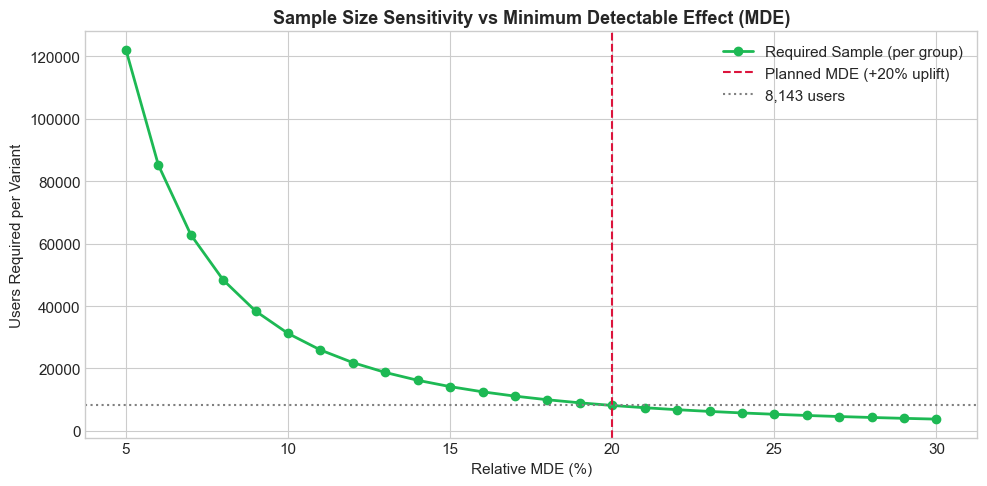

In [9]:
mde_range = np.linspace(0.05, 0.30, 26)  # From +5% to +30% relative uplift
sample_sizes = []

for mde in mde_range:
    p2 = baseline_cr * (1 + mde)
    eff_sz = sms.proportion_effectsize(baseline_cr, p2)
    n_req = power_analysis.solve_power(effect_size=eff_sz, power=power, alpha=alpha, ratio=1.0)
    sample_sizes.append(int(np.ceil(n_req)))

plt.figure(figsize=(10, 5))
plt.plot(mde_range * 100, sample_sizes, marker='o', color='#1DB954', linewidth=2, label='Required Sample (per group)')
plt.axvline(x=20, color='crimson', linestyle='--', label='Planned MDE (+20% uplift)')
plt.axhline(y=required_n, color='gray', linestyle=':', label=f'{required_n:,} users')
plt.title('Sample Size Sensitivity vs Minimum Detectable Effect (MDE)', fontsize=13, weight='bold')
plt.xlabel('Relative MDE (%)')
plt.ylabel('Users Required per Variant')
plt.legend()
plt.tight_layout()
plt.savefig('../assets/power_analysis_curve.png', dpi=300)
plt.show()

### 3. Traffic Duration Estimation
Estimate experiment runtime based on daily active users visiting the checkout flow.

In [10]:
daily_checkout_traffic = 3500  # Assumed daily users arriving at paywall
estimated_days = int(np.ceil(total_n / daily_checkout_traffic))

print(f"Assumed Daily Checkout Volume: {daily_checkout_traffic:,} users/day")
print(f"Minimum Test Duration: {estimated_days} days to reach full statistical power.")
print("Recommendation: Run test for at least 14 days to capture full weekly seasonality cycles.")

Assumed Daily Checkout Volume: 3,500 users/day
Minimum Test Duration: 5 days to reach full statistical power.
Recommendation: Run test for at least 14 days to capture full weekly seasonality cycles.
